In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")



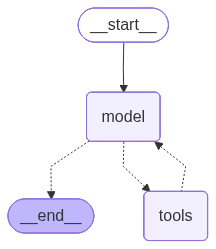

In [2]:
from langchain.agents import create_agent

def get_weather(city: str) -> str:
    """get_ipython().system('curl wttr.in/{city}?format=3')"""
    return f"The weather in {city} is sunny with a high of 25°C."

agent = create_agent(
    model="gpt-4",
    tools=[get_weather],
    system_prompt="You are a helpful assistant")

agent

In [4]:
# agent.invoke({"messages": [{"role": "user", "content": "What's the weather like in New York?"}]})

### Model integration with openai, google gemini, groq

In [3]:
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [4]:
from langchain.chat_models import init_chat_model
model= init_chat_model("gpt-4.1")

model

ChatOpenAI(output_version=None, profile={'name': 'GPT-4.1', 'release_date': '2025-04-14', 'last_updated': '2025-04-14', 'open_weights': False, 'max_input_tokens': 1047576, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x000001808E07F750>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001808E07F110>, root_client=<openai.OpenAI object at 0x000001808E07ED50>, root_async_client=<openai.AsyncOpenAI object at 0x000001808E07FED0>, model_name='gpt-4.1', model_kwargs={}, openai_

In [2]:
from langchain_groq import ChatGroq
llm = ChatGroq(
    model="llama-3.3-70b-versatile"
)

In [7]:
# model.invoke("hi")

In [5]:
## Gemini model test

from langchain.chat_models import init_chat_model
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
model = init_chat_model("google_genai:gemini-2.5-flash")

responses = model.invoke("hi")

In [6]:
responses.content

'Hello! How can I help you today?'

In [7]:
for chunks in model.stream("how humans are different from animals?"):
    print(chunks.text, end="|", flush=True)

While humans are biologically classified as animals (specifically, Homo sapiens, a type of primate mammal), there| are several key differences that distinguish us significantly from other animal species. These differences are often matters of *degree* and *complexity* rather than absolute presence or absence, but their combined effect creates a unique human experience.

Here are some of the most prominent| differences:

1.  **Complex Language and Symbolic Thought:**
    *   **Humans:** Possess highly complex, grammatical, symbolic language systems (both spoken and written) that allow for the communication of abstract ideas, past events, future plans|, emotions, and cumulative knowledge across generations. We can create and understand symbols that represent things not physically present.
    *   **Animals:** Communicate through various means (vocalizations, body language, chemical signals), but these systems are generally less| complex, less abstract, and lack the grammatical structure 

In [11]:
from langchain.tools import tool

@tool
def get_weather(city: str) -> str:
    """get weather information for a given city"""
    return f"The weather in {city} is sunny with a high of 25°C."

model_with_tools = model.bind_tools([get_weather])

In [12]:
responses = model_with_tools.invoke("What's the weather like in New York?")
print(responses)

content='' additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"city": "New York"}'}, '__gemini_function_call_thought_signatures__': {'5b132b0f-8de2-4c57-9028-6fc15349058c': 'Cp4CAQw51sfEZjOqfSysB5OviZbdpPPtHLKvbetKJjJ/fD4D4o2KtIhz3VOckhG+gC7ykrQnd4UJNmjfaLZgXHbBKqMdVxHbtgug4Efee78riyPhseIidMjUqx9hBiazfdH24a75/BhEZqW3rsFq0wZEUJ1tDyr5PD/0uXnNE/uS+pwQw26aXDq9JN9RuVvAi64Bn/lRW49YwPkUweBBuWSjfI9QlHwH0nXDPvwhTTfqNhUNQdBQciTaanWK8Xfkn2QBUxeGpL71eToR45CLlrOmCOLaLuOrguu+jI/c+0ur5K5nSLTUmjXtVNW9C1SyuidMf9U/8HcLHlkdo5yKCThSFhMaXXFPjAvs3z/UooqgROLxXtWB9mHV2cL9iXR17Q=='}} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--019e8c42-32ae-7910-8061-e88ff00652ca-0' tool_calls=[{'name': 'get_weather', 'args': {'city': 'New York'}, 'id': '5b132b0f-8de2-4c57-9028-6fc15349058c', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 50, 'output_tokens': 81, 'total_toke

In [13]:
from langchain.messages import HumanMessage, AIMessage, SystemMessage

messages = [
    SystemMessage(content="You are a ai engineer"),
    HumanMessage(content="What's ai engineering?")
]

responses = model.invoke(messages)
responses.content

"AI Engineering is the discipline of applying engineering principles and practices to the design, development, deployment, and maintenance of Artificial Intelligence (AI) and Machine Learning (ML) systems.\n\nThink of it as the bridge between the theoretical world of data science and machine learning research, and the practical world of production-ready, scalable, reliable, and ethical AI applications.\n\nHere's a breakdown of what that entails:\n\n### Core Focus Areas of AI Engineering:\n\n1.  **Bridging the Gap:** AI Engineers take experimental ML models (often developed by data scientists or ML researchers) and transform them into robust, production-grade applications that can be used by end-users or integrated into larger systems.\n\n2.  **MLOps (Machine Learning Operations):** This is arguably the heart of AI Engineering. MLOps encompasses the entire lifecycle of an ML model, from data acquisition and model training to deployment, monitoring, and continuous improvement. It involve

In [14]:
### Message with metadata

human_msg = HumanMessage(
    content="What's ai engineering?", 
    name='dev',
    id='msg_123')

In [16]:
responses = model.invoke([human_msg])
responses.content

'AI Engineering is a specialized field that focuses on **designing, building, and maintaining AI systems and applications in a production environment.** It bridges the gap between theoretical AI research and practical, scalable, and reliable real-world deployment.\n\nThink of it this way: Data Scientists and AI Researchers often develop the *models* (the "brain" of the AI). AI Engineers are the ones who build the *body* and the *nervous system* around that brain, ensuring it can function effectively, reliably, and efficiently in the real world.\n\nHere\'s a breakdown of what AI Engineering entails:\n\n1.  **Productionizing AI Models:** Taking experimental AI models (developed by Data Scientists or AI Researchers) and turning them into robust, scalable, and maintainable applications that can serve users or integrate into existing systems.\n\n2.  **Building AI Infrastructure:** Designing and implementing the underlying systems, tools, and pipelines necessary for the entire AI lifecycle, 

### Pydantic 
#### Pydantic model provide riches feature set with field validation, descriptions, nested structures

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
model = init_chat_model("google_genai:gemini-2.5-flash")

In [ ]:
import os
from langchain.chat_models import init_chat_model
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
model = init_chat_model("groq:qwen/qwen3-32b")
model


ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001BFE2496AD0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001BFE2497D90>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [31]:
from pydantic import BaseModel, Field

class Movie(BaseModel):
    title: str = Field(description="the name of the movie")
    year: int = Field(description="the release year of the movie")
    director: str = Field(description="the director of the movie")
    rating: float = Field(description="the rating of the movie out of 10")
    discriptions : str = Field(description="a brief description of the movie")

In [32]:
model_with_struc = model.with_structured_output(Movie)

In [33]:
model_with_struc

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001BFE2496AD0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001BFE2497D90>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'Movie', 'description': '', 'parameters': {'properties': {'title': {'description': 'the name of the movie', 'type': 'string'}, 'year': {'description': 'the release year of the movie', 'type': 'integer'}, 'director': {'description': 'the director of the movie', 'type': 'string'}, 'rating': {'description': 'the rating of the movie o

In [29]:
model.invoke("What are the details of the movie Inception?")

AIMessage(content='<think>\nOkay, so the user is asking about the movie "Inception." Let me start by recalling what I know. Directed by Christopher Nolan, right? It\'s a sci-fi action film. I think it\'s about dreams and something to do with entering people\'s dreams. The main character might be Dom Cobb, played by Leonardo DiCaprio. He\'s a thief who steals secrets by infiltrating the subconscious. \n\nThe plot probably involves a heist, but instead of stealing, they\'re trying to plant an idea. That\'s called "inception," which is the main concept. There\'s a team with different roles. Arthur, the second-in-command, played by Joseph Gordon-Levitt, who also does some cool action sequences. There\'s a woman named Mal, Cobb\'s wife, who might be a projection from his subconscious, causing him problems in the dream world.\n\nThe structure of the movie has multiple layers of dreams, each deeper than the last, with time passing faster as you go deeper. The idea is that you can manipulate t

In [34]:
model_with_struc.invoke("Tell me about the movie Inception.")

Movie(title='Inception', year=2010, director='Christopher Nolan', rating=8.8, discriptions='A thief who steals corporate secrets through the use of dream-sharing technology is given the inverse task of planting an idea into the mind of a C.E.O.')

### Nested Structure

In [36]:
class Actor(BaseModel):
    name: str = Field(description="the name of the actor")
    role: str = Field(description="the role of the actor in the movie")

class MoviewithActor(BaseModel):
    title: str = Field(description="the name of the movie")
    year: int = Field(description="the release year of the movie")
    director: str = Field(description="the director of the movie")
    rating: float = Field(description="the rating of the movie out of 10")
    discriptions : str = Field(description="a brief description of the movie")
    actors: list[Actor] = Field(description="the list of actors in the movie")
    genres: list[str] = Field(description="the genres of the movie")
    budget: int = Field(description="the budget of the movie in million dollars")

model_with_struc_actor = model.with_structured_output(MoviewithActor)

response = model_with_struc_actor.invoke("Tell me about the movie Inception.")
response


MoviewithActor(title='Inception', year=2010, director='Christopher Nolan', rating=8.8, discriptions="A thief who enters the dreams of others to steal secrets is given a final task of planting an idea into someone's mind.", actors=[Actor(name='Leonardo DiCaprio', role='Dom Cobb'), Actor(name='Joseph Gordon-Levitt', role='Arthur'), Actor(name='Ellen Page', role='Ariadne'), Actor(name='Tom Hardy', role='Jason')], genres=['Science Fiction', 'Action', 'Heist'], budget=160)

### TypedDict
#### Typedict provides a simpler alternative using python built in typing, ideal when we dont want run time validation.

In [37]:
from typing_extensions import Annotated, TypedDict

class MovieDict(TypedDict):
    title: Annotated[str, ..., "the name of the movie"]
    year: Annotated[int, ..., "the release year of the movie"]
    director: Annotated[str, ..., "the director of the movie"]
    rating: Annotated[float, ..., "the rating of the movie out of 10"]

model_with_typedict = model.with_structured_output(MovieDict)
response = model_with_typedict.invoke("Tell me about the movie Inception.")
response

{'director': 'Christopher Nolan',
 'rating': 8.8,
 'title': 'Inception',
 'year': 2010}

In [ ]:
class ContactInfo(BaseModel):
    name: str = Field(description="the name of the contact")
    email: str = Field(description="the email of the contact")
    phone: str = Field(description="the phone number of the contact")

agent = create_agent(
    model="gpt-5",
    response_format=ContactInfo,
    system_prompt="You are a helpful assistant that provides contact information.")

result = agent.invoke({"messages": [{"role": "user", "content": "What's the contact information for John Doe?, john.doe@example.com, 123-456-7890"}]})

result

### Data Class
#### A dataclass is a class mainly contain data, although they aren't really any restrictions. create it using @dataclass decorator

In [ ]:
from dataclasses import dataclass

@dataclass
class ContactInfoDataclass:
    name: str
    email: str
    phone: str

agent_dataclass = create_agent(
    model="gpt-5",
    response_format=ContactInfoDataclass,
    system_prompt="You are a helpful assistant that provides contact information.")

result_dataclass = agent_dataclass.invoke({"messages": [{"role": "user", "content": "What's the contact information for John Doe?"}]})
result_dataclass